# Week 7 — Day 1: Gradient Boosting Foundations
Today’s goal:

- Understand boosting intuitively
- Understand the math behind residual fitting
- Understand why gradients appear
- Build the mental model needed for XGBoost later

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
# Dataset
X=np.array([1,2,3,4,5]).reshape(-1,1)
y=np.array([10,20,50,60,70])
y_mean=y.mean() # Initial Prediction

residuals=y-y_mean # Compute Residuals
residuals

array([-32., -22.,   8.,  18.,  28.])

In [3]:
tree1=DecisionTreeRegressor(max_depth=1)
tree1.fit(X,residuals)

pred1=tree1.predict(X)
pred1

lr=0.1
f0=y_mean+lr*pred1

new_residual=y-f0
new_residual

array([-29.3, -19.3,   6.2,  16.2,  26.2])

In [4]:
X=np.array([1,2,3,4,5]).reshape(-1,1)
y=np.array([5,7,9,11,13])
F=np.full(len(y),np.mean(y))

learning_rate=0.1
n_trees=5
models=[]

for i in range(n_trees):
  residuals=y-F

  tree=DecisionTreeRegressor(max_depth=1)
  tree.fit(X,residuals)

  pred=tree.predict(X)

  F+=learning_rate*pred
  models.append(tree)

  mse=mean_squared_error(y,F)
  print(f'''Iteration {i+1}
  Predictions: {F}
  MSE:{mse}
  {"-"*40}''')

Iteration 1
  Predictions: [8.7 8.7 9.2 9.2 9.2]
  MSE:6.859999999999999
  ----------------------------------------
Iteration 2
  Predictions: [8.51333333 8.51333333 9.01333333 9.48       9.48      ]
  MSE:5.866933333333333
  ----------------------------------------
Iteration 3
  Predictions: [8.34533333 8.34533333 8.84533333 9.732      9.732     ]
  MSE:5.062549333333334
  ----------------------------------------
Iteration 4
  Predictions: [8.1108     8.1108     9.00168889 9.88835556 9.88835556]
  MSE:4.365808130370371
  ----------------------------------------
Iteration 5
  Predictions: [ 7.9700237   7.9700237   8.86091259 10.09952    10.09952   ]
  MSE:3.8009961108016475
  ----------------------------------------


In [5]:
data=fetch_california_housing()

X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
learning_rate=[0.01,0.1,0.5]

for lr in learning_rate:
  model=GradientBoostingRegressor(
      learning_rate=lr,
      n_estimators=100,
      max_depth=3,
      random_state=42
  )
  model.fit(X_train,y_train)

  train_pred=model.predict(X_train)
  test_pred=model.predict(X_test)

  train_mse=mean_squared_error(y_train,train_pred)
  test_mse=mean_squared_error(y_test,test_pred)

  print(f'''Learning Rate: {lr}
  Train MSE: {train_mse}
  Test MSE: {test_mse}
  {"-"*40}''')

Learning Rate: 0.01
  Train MSE: 0.6498747671828304
  Test MSE: 0.6642879411474717
  ----------------------------------------
Learning Rate: 0.1
  Train MSE: 0.2608082607140481
  Test MSE: 0.2939973248643864
  ----------------------------------------
Learning Rate: 0.5
  Train MSE: 0.17753825708123308
  Test MSE: 0.24587887941423245
  ----------------------------------------


In [8]:
configs=[
    (0.1,50),
    (0.1,200),
    (0.01,500),
    (0.5,20)
]

for lr,n in configs:
  model=GradientBoostingRegressor(
      learning_rate=lr,
      n_estimators=n,
      max_depth=3,
      random_state=42
  )
  model.fit(X_train,y_train)

  train_score=model.score(X_train,y_train)
  test_score=model.score(X_test,y_test)

  print(f'''Learning Rate: {lr}, Trees={n}
  Train R^2:{train_score}
  Test R^2:{test_score}
{"--"*25}''')

Learning Rate: 0.1, Trees=50
  Train R^2:0.7687968962008667
  Test R^2:0.7434686073011577
--------------------------------------------------
Learning Rate: 0.1, Trees=200
  Train R^2:0.8358544068105361
  Test R^2:0.8004451261281281
--------------------------------------------------
Learning Rate: 0.01, Trees=500
  Train R^2:0.7669414105134016
  Test R^2:0.7414623333718753
--------------------------------------------------
Learning Rate: 0.5, Trees=20
  Train R^2:0.7965014793333086
  Test R^2:0.7651317151662591
--------------------------------------------------


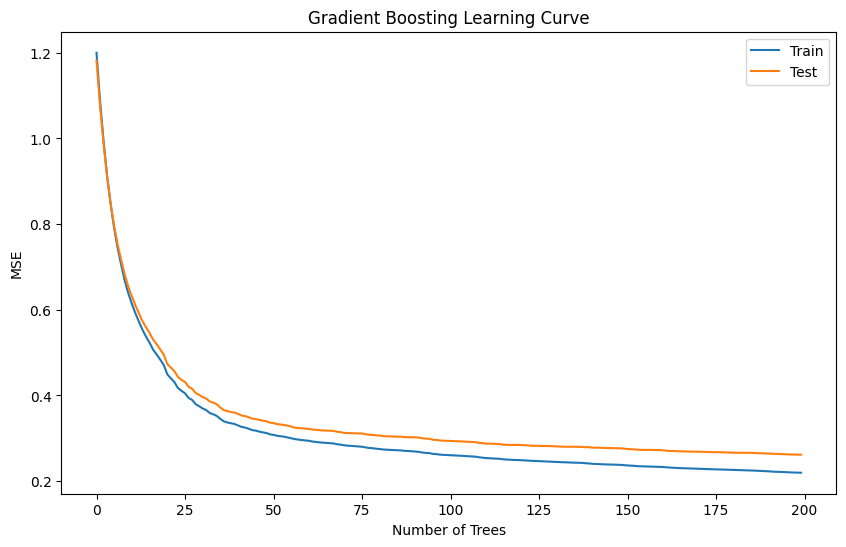

In [9]:
model=GradientBoostingRegressor(
      learning_rate=0.1,
      n_estimators=200,
      max_depth=3,
      random_state=42
  )
model.fit(X_train,y_train)
train_error=[]
test_error=[]
for pred_train,pred_test in zip(
    model.staged_predict(X_train),
    model.staged_predict(X_test)
):
  train_error.append(mean_squared_error(y_train,pred_train))
  test_error.append(mean_squared_error(y_test,pred_test))
plt.figure(figsize=(10,6))
plt.plot(train_error,label='Train')
plt.plot(test_error,label='Test')
plt.xlabel('Number of Trees')
plt.ylabel('MSE')
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.show()

In [10]:
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
gb=GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train,y_train)
gb.fit(X_train,y_train)
rf_score=rf.score(X_test,y_test)
gb_score=gb.score(X_test,y_test)
print(f'''Random Forest R^2: {rf_score}
Gradient Boosting R^2: {gb_score}''')

Random Forest R^2: 0.8051230593157366
Gradient Boosting R^2: 0.7756446042829697


In [11]:
model=GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train,y_train)
importance=pd.DataFrame({
    "Feature":data.feature_names,
    "Importance":model.feature_importances_
})
importance=importance.sort_values(
    by="Importance",
    ascending=False,

)
print(importance)

      Feature  Importance
0      MedInc    0.604259
5    AveOccup    0.122835
7   Longitude    0.109853
6    Latitude    0.098533
1    HouseAge    0.034113
2    AveRooms    0.023948
3   AveBedrms    0.005106
4  Population    0.001354


In [12]:
model = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=1.0,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.9999999999999986
Test Score: 0.6378134607881372
